<a href="https://colab.research.google.com/github/Utsav-exe/HAR-Machine-Learning/blob/main/har.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

!git clone https://github.com/Utsav-exe/HAR-Machine-Learning.git
%cd HAR-Machine-Learning
!wget "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
!unzip -q "UCI HAR Dataset.zip"

Cloning into 'HAR-Machine-Learning'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 4.62 KiB | 789.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/HAR-Machine-Learning/HAR-Machine-Learning
--2026-04-01 14:59:38--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [        <=>         ]  58.17M  37.6MB/s    in 1.5s    

2026-04-01 14:59:39 (37.6 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, names=['ID', 'Activity'])
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['ID', 'Sensor_Feature'])

print("Activity Map:")
print(activity_labels)
print(f"\nTotal Features found: {len(features)}")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2751/2457569251.py:5: SyntaxWarning: invalid escape sequence '\s'
  activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, names=['ID', 'Activity'])
/tmp/ipykernel_2751/2457569251.py:6: SyntaxWarning: invalid escape sequence '\s'
  features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['ID', 'Sensor_Feature'])


Activity Map:
   ID            Activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING

Total Features found: 561


In [6]:

X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)#sensor data
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)#activity id
X_train.columns = features['Sensor_Feature']#assigning 561 features as columns in x_train
X_train['Activity_ID'] = y_train[0]#which row belongs to which activity

print(f"Data Loaded! Shape: {X_train.shape}")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2751/2590463723.py:1: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)#sensor data
/tmp/ipykernel_2751/2590463723.py:2: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)#activity id


Data Loaded! Shape: (7352, 562)


/tmp/ipykernel_2751/1894303920.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_names, y=activity_counts.values, palette='viridis')


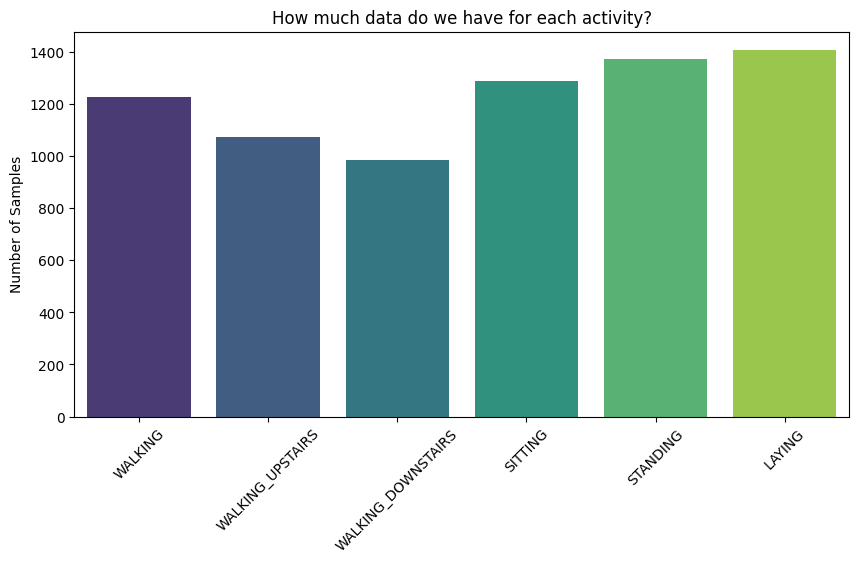

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep=r'\s+', header=None, names=['ID', 'Name'])#activity names
activity_counts = y_train[0].value_counts().sort_index()#counting number of time activity occurs
activity_names = labels['Name'].values
plt.figure(figsize=(10, 5))#plot
sns.barplot(x=activity_names, y=activity_counts.values, palette='viridis')
plt.title('How much data do we have for each activity?')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

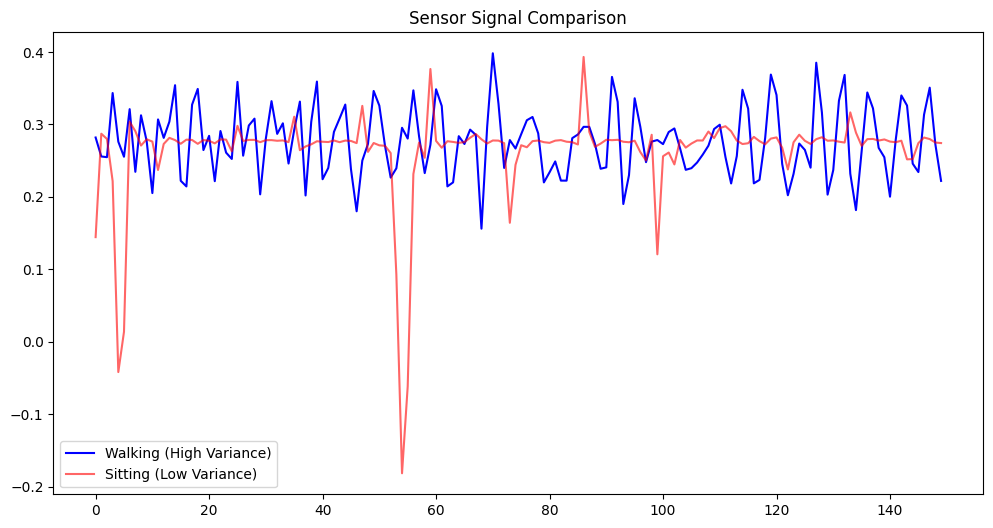

In [9]:
#'WALKING' vs 'SITTING'
plt.figure(figsize=(12,6))

X_train['ActivityName'] = X_train['Activity_ID'].map(activity_labels.set_index('ID')['Activity'])

walking = X_train[X_train['ActivityName'] == 'WALKING']['tBodyAcc-mean()-X'].iloc[:150]
sitting = X_train[X_train['ActivityName'] == 'SITTING']['tBodyAcc-mean()-X'].iloc[:150]

plt.plot(walking.values, label='Walking (High Variance)', color='blue')
plt.plot(sitting.values, label='Sitting (Low Variance)', color='red', alpha=0.6)

plt.title('Sensor Signal Comparison')
plt.legend()
plt.show()